In [1]:
import pandas as pd
import scipy.stats as sp
import matplotlib.pyplot as plt
import numpy as np

from planet_builder import *

# Project 3
### The goal of this project is to combine most of what we have learned so far into a single project. I'm going to ...

### Part 1 -- M-R relationships for "small planets"
#### Step 1: sample selection
- Download the default parameter set from NEA
- Remove controversial planets
- Remove planets that DO NOT have BOTH mass and radius measurements
    - This means you should remove planets that only have minimum mass or radius measurements too
- Use the mass and radius measurements to calculate density and density uncertainties
- Remove planets with density uncertainties >= 25%
- Finally use the Van Eylen Period-dependent radius gap to remove likely sub-Neptunes from your sample (https://ui.adsabs.harvard.edu/abs/2018MNRAS.479.4786V/abstract)
- Plot the final sample on a M-R plot, Density-R plot, or, better, yet do both.
- Add the Solar System rocky planets!!

#### Step 2: Build isocompositional M-R relationships from pure-Fe to pure water
For this step, I want you to build isocomp M-R curves spanning from pure iron to pure H2O. I have provided you with two planet builders (which are imported above from the planet_builder file):  build_rocky_planet and build_wet_planet.

build_rocky_planet creates core+mantle planet, i.e., a purely rocky planet (WMF = 0). The inputs you will need are (in this order):
- mass -- planet mass in Earth masses
- cmf -- core mass fraction
- core_eos -- equation of state for the core material
- mantle_eos -- equation of state suite for the mantle materials

build_wet_planet does the same thing with the added complexity that it includes an outer hydrosphere. The required inputs are (in this order):
- mass -- planet mass in Earth masses
- cmf -- core mass fraction (of the rocky portion of the planet -- ask me)
- wt_frac_water -- planet water mass fraction (i.e., how much of the total mass do you want to be water/ice?)
- core_eos
- mantle_eos
- h2o_eos
*** For all water worlds, you should pick one CMF value and hold it fixed. You will need to justify your choice of CMF.


You will need to select one of the built in core_eos you want to use from the following list and justify your choice:
- Anderson_lFe -- experimental EOS for liquid Fe from https://agupubs.onlinelibrary.wiley.com/doi/10.1029/93JB03158
- Smith_sFe -- experimental EOS for hcp-Fe from https://duffy.princeton.edu/sites/g/files/toruqf616/files/media/smith-2018-nature.pdf

For the mantle, pick one of the following and justify:
- EP_mantle -- includes upper mantle phase transitions (https://iopscience.iop.org/article/10.3847/1538-4357/acaa3b)
- magrathea_mant -- uses the default mantle EOS suite from https://academic.oup.com/mnras/article/513/4/5256/6574421

For the hydrosphere, pick one and justify:
- EP_h2o -- https://iopscience.iop.org/article/10.3847/1538-4357/acaa3b
- sotin_h2o -- from https://ui.adsabs.harvard.edu/abs/2007Icar..191..337S/abstract

### You will need to cite all EsOS you pick.

### While you aren't expected to make your own planet builder for this project, I would still like you to describe how the one I have given you works in your report. The planet builder is based off of ExoPlex which is described in Section 2 of https://iopscience.iop.org/article/10.3847/1538-4357/acaa3b/pdf (just the intro of this section -- stop before 2.1) and was discussed in lecture.


#### The cell below shows two examples of isocomposition lines using these two functions 


In [2]:
mass_array = 10**(np.linspace(-1, 1, 20))
radius_wmf_50 = np.array([])
radius_cmf_70 = np.array([])

for mass in mass_array:
    pressure_array, density_array, radius_array, mhold = build_wet_planet(mass, 0.29, 0.5, Smith_sFe, EP_mantle, EP_h2o)
    radius_wmf_50 = np.append(radius_wmf_50, radius_array[-1]/re)
    
    pressure_array, density_array, radius_array, mhold = build_rocky_planet(mass, 0.7, Smith_sFe, EP_mantle)
    radius_cmf_70 = np.append(radius_cmf_70, radius_array[-1]/re)
    

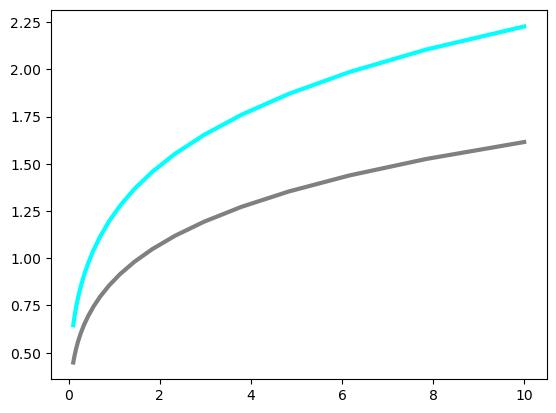

In [3]:
plt.plot(mass_array, radius_cmf_70, color = 'gray', lw = 3)
plt.plot(mass_array, radius_wmf_50, color = 'cyan', lw = 3)

### Part 2 -- Reproducing the nominally rocky planet zone (NRPZ) from https://iopscience.iop.org/article/10.3847/1538-4357/acaa3b


#### Step 1: The first thing we are going to do is load in Fe, Mg, and Si abundances from the Hypatia catalog (https://www.hypatiacatalog.com/hypatia) and convert them to molar Fe/Mg and Si/Mg ratios
    I'm going to do this step for you with a short explanation since this more along the lines of 'Stellar Astronomy' than planetary science, but it is still good to be aware of the basics b/c it does come up in PS.
    
    Stellar abundance values in Hypatia and pretty much everywhere in the literature are usually given as [X/H] where 
    
$$\left[\frac{X}{H}\right] = \log_{10}\left(\frac{N_{X}}{N_{H}}\right)_\star - \log_{10}\left(\frac{N_{X}}{N_{H}}\right)_\odot$$

    
    so the abundance of element X is normalized to that of Hydrogen (usually just assumed to be 10^12) and compared to the Sun. This is a similar concept to Stellar magnitude scales. For iron, this would be
    
$$\left[\frac{Fe}{H}\right] = \log_{10}\left(\frac{N_{Fe}}{N_{H}}\right)_\star - \log_{10}\left(\frac{N_{Fe}}{N_{H}}\right)_\odot$$
    
    
    
    We want to get these into molar ratios of Fe/Mg and Si/Mg to calculate planet composition:
    
$$\Large \frac{Fe}{Mg} = \frac{10^{[Fe/H] \; + \; \log_{10}(N_{Fe}/N_{H})_\odot}}{10^{[Mg/H] \; + \; \log_{10}(N_{Mg}/N_{H})_\odot}}$$

    and
    
 $$\Large \frac{Si}{Mg} = \frac{10^{[Fe/H] \; + \; \log_{10}(N_{Si}/N_{H})_\odot}}{10^{[Mg/H] \; + \; \log_{10}(N_{Mg}/N_{H})_\odot}}$$   
    

In the cell below I'm using values for $\log_{10}(N_{Fe}/N_{H})_\odot$, $\log_{10}(N_{Mg}/N_{H})_\odot$, and $\log_{10}(N_{Si}/N_{H})_\odot$ from Lodders+ 2009 (https://materials.springer.com/lb/docs/sm_lbs_978-3-540-88055-4_34). 

*** For your report, you don't need to include the above equations or describe this step in detail (unless you find it to be a useful exercise), but you should cite the Lodders paper, describe the Hypatia Catalog in 1-2 sentences, and cite the relevant Hypatia paper by Natalie Hinkel. Think something along the lines of "We use a sample of [Fe/H], [Si/H], and [Mg/H] values from the Hypatia stellar abundance database. 1-2 SENTENCE DESCRIPTION OF HYPATIA + CITATION. We convert these to molar Fe/Mg and Si/Mg ratios using the Solar values of $\log_{10}(N_{Si}/N_{H})_\odot = XX$, $\log_{10}(N_{Mg}/N_{H})_\odot = XX$, and $\log_{10}(N_{Fe}/N_{H})_\odot = XX$ from (citation to the Lodders 2009 paper)" You should use these words as a reference -- you will need to rewrite in your own words ***
    
    
Natalie Hinkel has a nice paper on all of the above and more if you are interested:  https://iopscience.iop.org/article/10.3847/1538-3881/ac9bfa/pdf 
    

In [4]:
hypatia = pd.read_csv('hypatia.csv')
FeMg = 10**((hypatia['Fe'] + 7.45) - (hypatia['Mg'] + 7.54))
SiMg = 10**((hypatia['Si'] + 7.52) - (hypatia['Mg'] + 7.54))

#### Step 2: Define a function that converts the molar ratios into planet core mass fraction. You should assume a pure iron core and Fe-free silicate mantle made entirely of MgO and SiO2.

##### The Fe/Mg and Si/Mg ratios of the Sun are ~0.81 and ~0.95, respectively which should give CMF = 0.317. Use this to check yourself. Is this CMF broadly consistent with Earth?

In [5]:
def get_CMF(FeMg, SiMg):
    #your equation goes here. you will need to define some constants too
    return cmf
    

#### Step 3: use your function to convert your Fe/Mg and Si/Mg values to a CMF distribution. Find the median or average CMF value and the  99.7% CMF range. I would like to see a histogram plot of the CMF distribution and the median/average values + the 99.7% data range shown as well.
    There are two main ways you can try getting the 99.7% data range: fitting the data to some theoretical distribution (e.g., a Guassian) or calculating the data percentiles directly. Here are two links to help you get moving: 
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html 
    https://numpy.org/doc/stable/reference/generated/numpy.quantile.html
    
    For plotting the histogram check out the plt.hist help page.
    
    Some other hints: for plt.hist you may find that you want to set the optional density parameter to true. Why? What does density = True do?
    
    

#### Step 4: Add the NRPZ to your plot(s)

You should now have three CMF values: (1) the median or average, (2) the lower bound of the 99.7% data range, and (3) the upper bound of the 99.7% data range. The latter two values define the NRPZ, but I would like you to add isocomposition lines for all three values to your plot(s). Make sure these are labeled and clearly distinguishable from the other isocomp lines on your plot(s)!

If you feel your plot(s) are getting too busy, you are welcom to create a new set with just the NRPZ lines + the planet sample. Both sets should still go in your report.


#### Step 5: Interpret a few planets
Read through section 9 of Unterborn+ 2023 (https://iopscience.iop.org/article/10.3847/1538-4357/acaa3b/pdf) and look at Figure 17. From your sample, I would like you to discuss 1 strong Fe-rich planet, 1 strong low density planet (Cayman calls these "Volatile-rich mini-Neptunes or Water-worlds" in his paper -- while not wrong, I think this term does too much 'lumping'), and one planet that falls within the NRPZ. Highlight these three planets on your plot(s). You should also look at the previous literature on your selected planets.


### Part 3 -- model your favorite small Solar System object
By small, I mean anything that isn't Jupiter, Saturn, Uranus, Neptune, or the Sun. Otherwise, go crazy! Pick an object and then let's discuss the steps for this part together b/c they will differ based on your choice of planet. This is going to be the 'above-and-beyond' portion of this project.

